# Maintenance, Failure Analysis
__Midterm COMP3250__

DATE: 02/25/2026

### 1\. a) View data and load into __dataframe__
* Using the pandas library, assign the result of loading the data into a pandas datraframe to the __maintenanceDf__ variable

In [ ]:
# Import pandas to load dataframe from CSV file
import pandas as pd
# Start at the first column 'UDI'. This just corresponds to the idex of each sample in the dataset
maintenanceDf = pd.read_csv('maintenance_dataset.csv', index_col=0)
# Ensure the maintenance dataset was loaded correctly 
maintenanceDf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9928 entries, 1 to 10000
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Product_ID              9928 non-null   object 
 1   Type                    9928 non-null   object 
 2   Air_temperature_K_      9928 non-null   float64
 3   Process_temperature_K_  9928 non-null   float64
 4   Rotational_speed_rpm_   9928 non-null   int64  
 5   Torque_Nm_              9928 non-null   float64
 6   Tool_wear_min_          9928 non-null   int64  
 7   Failure_Type            9928 non-null   object 
dtypes: float64(3), int64(2), object(3)
memory usage: 698.1+ KB


### b) Check for empty values

* Starting with the __isna__ method applied on the __maintenanceDf__ variable. Normally the method will return false in any value that's anything other than empty.
* Next, we chain the sum method to return the number of empty entries in each column

In [ ]:
maintenanceDf.isna().sum()

Product_ID                0
Type                      0
Air_temperature_K_        0
Process_temperature_K_    0
Rotational_speed_rpm_     0
Torque_Nm_                0
Tool_wear_min_            0
Failure_Type              0
dtype: int64

Therefore, since the sum of each and every null feature is __zero__, there are no empty or missing values within the dataset. This means we don't require an imputer data transformation, however, we still need to encode the categorical data and the target feature to generate a valid model.

### c) Encode the categorical and target features

Begin by importing OneHotEncoder and LabelEncoder from sklearn.preprocessing. After, separate, the features by data type and drop ProductID as this is totally unique and will just be memorized. This column may also cause overfitting.

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

categorical_feat = "Type"

numeric_feat = ["Air_temperature_K_", "Process_temperature_K_", "Rotational_speed_rpm_", 
                "Torque_Nm_", "Tool_wear_min_"]

target_feat = "Failure_Type"

In [ ]:
# Create a label encoder
catLabelEn = LabelEncoder()
# Encode the "Failure_Type" column using the label encoder. Assign this to the target_encoded variable
target_encoded = catLabelEn.fit_transform(maintenanceDf[target_feat])

#Create an encoder for the other categorical data. In this case, it is only the "Type" feature
catHotEn = OneHotEncoder(sparse_output=False)
# Encode the "Type" column using the one hot encoder. Assign this to the
categories_encoded = catHotEn.fit_transform(maintenanceDf[[categorical_feat]])

Both are numpy arrays now containing numerical value representations of the categories they have been derived from.

In [ ]:
categories_encoded

array([[0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       ...,
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.]])

In [ ]:
target_encoded

array([0, 0, 0, ..., 0, 0, 0])

Next, assign the target feature to *__y__* and the features which we are trying to find a relationship with y, to *__X__*\.

In [ ]:
# Convert the encoded category array to the correct dataframe. Ensure that the columns and rows are lined up as well. Use the get_feature_names_out method to retrieve column names
categories_encodedDf = pd.DataFrame(categories_encoded, columns=catHotEn.get_feature_names_out([categorical_feat]), index=maintenanceDf.index)

# Concatenate the dataframes for all features involved in X
X = pd.concat([maintenanceDf[numeric_feat], categories_encodedDf], axis=1)
# Assign the target, y, to the target_encoded array
y = target_encoded

In [ ]:
X # All features numerical

,Air_temperature_K_,Process_temperature_K_,Rotational_speed_rpm_,Torque_Nm_,Tool_wear_min_,Type_H,Type_L,Type_M
UDI,,,,,,,,
1,298.1,308.6,1551,42.8,0,0.0,0.0,1.0
2,298.2,308.7,1408,46.3,3,0.0,1.0,0.0
3,298.1,308.5,1498,49.4,5,0.0,1.0,0.0
4,298.2,308.6,1433,39.5,7,0.0,1.0,0.0
5,298.2,308.7,1408,40.0,9,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...
9996,298.8,308.4,1604,29.5,14,0.0,0.0,1.0
9997,298.9,308.4,1632,31.8,17,1.0,0.0,0.0
9998,299.0,308.6,1645,33.4,22,0.0,0.0,1.0


In [ ]:
y # An array of encoded categories

array([0, 0, 0, ..., 0, 0, 0])

### d) Split data: Training Set, Test Set
Using the train_test_split function, we can split the dataset into two sets. Both to ensure accuracy and evaluate performance. This function comes from the linear_models utility inside of scikit-learn.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=12, stratify=y, test_size=0.25)

## 2\. Visualizing the distribution of Failure Types
Using pyplot in matplotlib

Text(0.5, 1.0, 'Frequency of Different Failure Types')

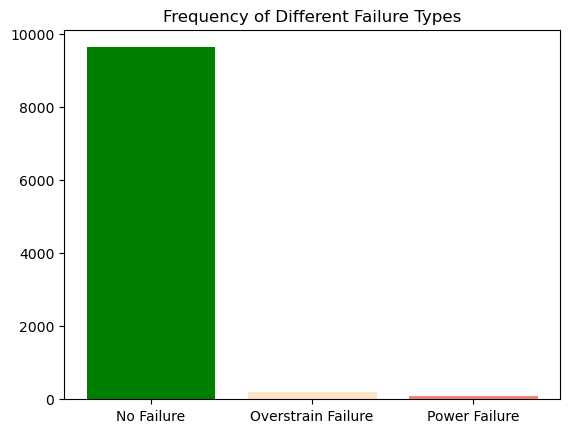

In [ ]:
import matplotlib.pyplot as plt
# Take the three possible values for the target column and plot it in a bar graph against the total sum of each value
plt.bar(maintenanceDf[target_feat].value_counts().index, maintenanceDf[target_feat].value_counts().values, color=["green", "bisque", "salmon"])
plt.title("Frequency of Different Failure Types")

From this graph, we can conclude that overstrain and power failures happen quite infrequently. We can even see this from the raw values provided by the value_count method.

array([[<Axes: title={'center': 'Air_temperature_K_'}>,
        <Axes: title={'center': 'Process_temperature_K_'}>],
       [<Axes: title={'center': 'Rotational_speed_rpm_'}>,
        <Axes: title={'center': 'Torque_Nm_'}>],
       [<Axes: title={'center': 'Tool_wear_min_'}>, <Axes: >]],
      dtype=object)

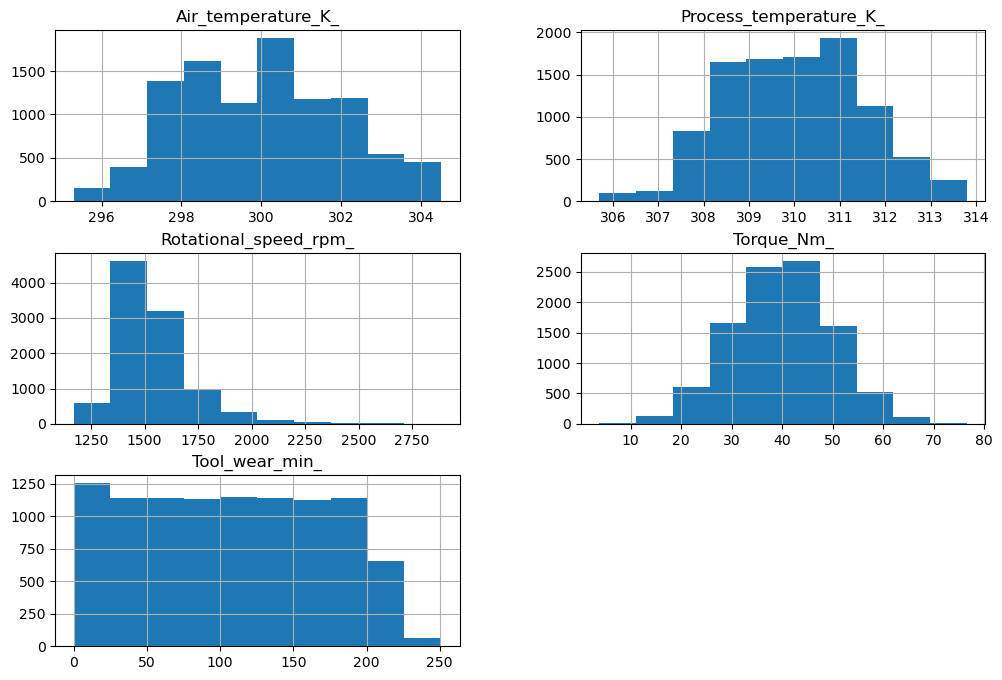

In [ ]:
maintenanceDf.hist(figsize=(12,8))

From these graphs, we can see the distribution of features quite a bit better through the use of a histogram.

<Axes: >

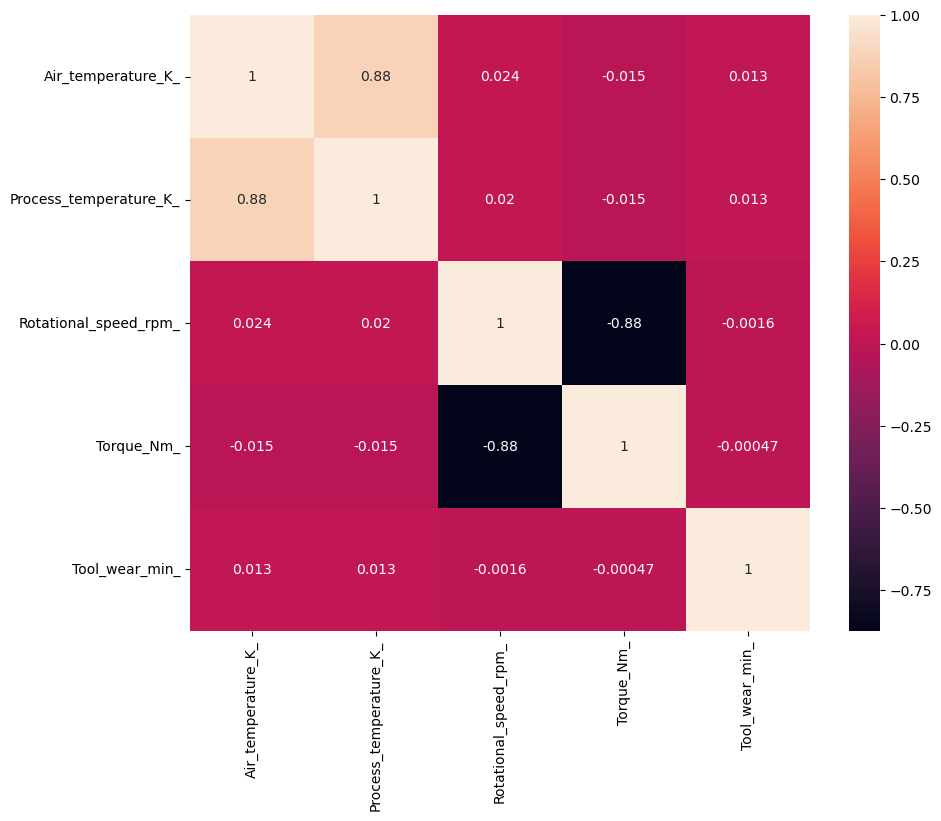

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(maintenanceDf.select_dtypes(include='number').corr(), annot=True)

Using a seaborn heatmap, we can plot the correlation coefficient of each field that is of type 'number'. This further puts into perspective, visually, how connected each feature may be. In this case, we can see that the air temperature is closely related to the process temperature and the torque is inversely related to the rotational speed in rpm. Thus, as air temperature increases, so does the process temperature. Similarily, as the torque increases, the rotational speed decreases and vice-versa.

The rest of the features displayed in the heatmap are very weakly related. Others aren't related at all given the infinitesimal values shown.

### 3\. Model Planning & Building

#### What kind of problem is it?

This problem is a __classification__ problem or more specificially, a __multi-classification__ problem. I know this because the target variable consists of three values. No failure, overstrain, and power failure. When building a model, we have to ensure that it will best predict future failures by categorizing entries into one of those three categories. 

Regression, on the other hand, is used when trying to find a relationship between continuous values. This is unlike the problem given. However, if the target were swapped with a numeric feature, regression might be the better choice.

#### Model Considerations:

Given that this is a nominal classification problem, the best choice of model could be the *random forest model* as this model is performs well in both regression and classification tasks, requires little hyperparameter tuning, and minimal data preparation.


#### a) Logistic regression will be the first model we will use due to its simplicity to implement. After, we will compare the performance to the random forest model.

In [ ]:
from sklearn.linear_model import LogisticRegression
# Logistic Regression model with enough iterations to converge
lr = LogisticRegression(max_iter=1500)
# Fit the model based on training data and then predict a target based on the X_test set.
lrPrediction = lr.fit(X_train, y_train).predict(X_test)

In [ ]:
# Test Score
lr.score(X_test, y_test)

0.9794520547945206

In [ ]:
# Training Score
lr.score(X_train, y_train)

0.9802578565672845

In [ ]:
from sklearn.metrics import classification_report
# For more stats based on our model, let's use the classification report function
classification_report(y_test, lrPrediction)

'              precision    recall  f1-score   support\n\n           0       0.98      1.00      0.99      2411\n           1       0.56      0.19      0.29        47\n           2       0.95      0.79      0.86        24\n\n    accuracy                           0.98      2482\n   macro avg       0.83      0.66      0.71      2482\nweighted avg       0.97      0.98      0.97      2482\n'

#### Score and Classification Report

At first, we can see that the logistic regression model performed quite well on both the training and test sets. However, when we look at the classification report, we can see a more accurate picture that places all categories into perspective.

Given that 0 = 'No Failure', 1 = 'Overstrain Failure', 2 = 'Power Failure',

We can see that the score for Overstrain Failure is lacking as only 19% of real overstrain failures are detected from the recall column. Not only that, but this model predicts 'No Failure' extremely well and 'Power Failure' quite a bit better than 'Overstrain Failure'. 

#### Why is this the case?

The given dataset is very imbalanced. Of 9,928 samples, only 190 are overstrain failures, 95 are power failures, and 9643 consist of no failure at all. This means the model doesn't have a ton of data points to choose from for better generalization. Thus, the way we may be able to correct this will be through the use of the *__Random Forest__* model which deals well with such imbalances and may find more connection between features.

In [ ]:
maintenanceDf[target_feat].value_counts().values

array([9643,  190,   95])

In [ ]:
pd.DataFrame({"Feature": X.columns, "Coefficient": lr.coef_[0] })

,Feature,Coefficient
0,Air_temperature_K_,-0.683661
1,Process_temperature_K_,0.795968
2,Rotational_speed_rpm_,-0.010409
3,Torque_Nm_,-0.406204
4,Tool_wear_min_,-0.006025
5,Type_H,0.235714
6,Type_L,-0.227400
7,Type_M,-0.004007


From this dataframe of feature importance, we can conclude that process temperature and air temperature are the most influential features from the dataset on the logistic regression model.

### b) Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# Random forest classifier model. Using 100 trees, no max depth, and class_weight of 'balanced' 
# given that our dataset is imbalanced
rf_model = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=12, class_weight='balanced')
rfPrediction = rf_model.fit(X_train, y_train).predict(X_test)

In [ ]:
rf_model.score(X_train, y_train)

1.0

In [ ]:
rf_model.score(X_test, y_test)

0.984286865431104

In [ ]:
classification_report(y_test, rfPrediction)

'              precision    recall  f1-score   support\n\n           0       0.98      1.00      0.99      2411\n           1       0.95      0.38      0.55        47\n           2       0.94      0.62      0.75        24\n\n    accuracy                           0.98      2482\n   macro avg       0.96      0.67      0.76      2482\nweighted avg       0.98      0.98      0.98      2482\n'

As you can see, the random forest model is a bit more balanced when it comes to predicting classes using imbalanced data. The issue with this model is that it is prone to overfitting, this is because with the training score at 100% and the test score at ~98%, the model recognizes the patterns within the training data and tries to apply them to new data. 

#### Check the feature importance

In [ ]:
pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})

,Feature,Importance
0,Air_temperature_K_,0.098954
1,Process_temperature_K_,0.068588
2,Rotational_speed_rpm_,0.295828
3,Torque_Nm_,0.405081
4,Tool_wear_min_,0.110170
5,Type_H,0.003765
6,Type_L,0.011179
7,Type_M,0.006435


From this dataframe of feature importance, we can conclude that the torque, rotational speed, and tool wear are the most important features to the random forest model.